##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

In [1]:
!pip install transformers datasets scikit-learn pillow matplotlib torch torchvision

In [2]:
!pip install --upgrade sympy

In [3]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix
from transformers import AutoImageProcessor, AutoModel, AutoModelForImageClassification

In [4]:
MODEL_ID = "facebook/dinov2-small"

device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model = AutoModel.from_pretrained(MODEL_ID).to(device)
model.eval()

print(f"Model {MODEL_ID} loaded on {device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Model facebook/dinov2-small loaded on cpu


### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

In [5]:
from torchvision.datasets import OxfordIIITPet
from torchvision import transforms

dataset = OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    download=True
)

print("Dataset size:", len(dataset))

100%|██████████| 792M/792M [00:21<00:00, 37.5MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 13.3MB/s]


Dataset size: 3680


In [6]:
cat_breeds = [
    'Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British_Shorthair',
    'Egyptian_Mau', 'Maine_Coon', 'Persian', 'Ragdoll', 'Russian_Blue',
    'Siamese', 'Sphynx'
]

selected_images = []
true_labels = []

cat_count = 0
dog_count = 0

for img, label in dataset:
    class_name = dataset.classes[label]

    if class_name in cat_breeds and cat_count < 10:
        selected_images.append(img)
        true_labels.append(0)
        cat_count += 1

    elif class_name not in cat_breeds and dog_count < 10:
        selected_images.append(img)
        true_labels.append(1)
        dog_count += 1

    if cat_count == 10 and dog_count == 10:
        break

print("Selected images:", len(selected_images))
print("Cats:", true_labels.count(0))
print("Dogs:", true_labels.count(1))

Selected images: 20
Cats: 10
Dogs: 10


In [7]:
def get_cls_embedding(img):
    img = img.convert("RGB")
    inputs = processor(images=img, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        cls_token = outputs.last_hidden_state[:, 0]
        cls_token = F.normalize(cls_token, p=2, dim=1)

    return cls_token.cpu().numpy().squeeze()

embeddings = []

for img in selected_images:
    embeddings.append(get_cls_embedding(img))

embeddings = np.array(embeddings)

print("Embeddings shape:", embeddings.shape)

Embeddings shape: (20, 384)


In [8]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings)

print("Cluster labels:", cluster_labels)
print("Ground truth:", true_labels)

Cluster labels: [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
Ground truth: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [9]:
true_labels_np = np.array(true_labels)

acc1 = accuracy_score(true_labels_np, cluster_labels)
acc2 = accuracy_score(true_labels_np, 1 - cluster_labels)

best_acc = max(acc1, acc2)

print("Accuracy:", best_acc)
print("Confusion matrix option 1:")
print(confusion_matrix(true_labels_np, cluster_labels))
print("Confusion matrix option 2:")
print(confusion_matrix(true_labels_np, 1 - cluster_labels))

Accuracy: 1.0
Confusion matrix option 1:
[[10  0]
 [ 0 10]]
Confusion matrix option 2:
[[ 0 10]
 [10  0]]


### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

In [10]:
CLASS_MODEL_ID = "facebook/dinov2-small-imagenet1k-1-layer"

class_processor = AutoImageProcessor.from_pretrained(CLASS_MODEL_ID)
class_model = AutoModelForImageClassification.from_pretrained(CLASS_MODEL_ID).to(device)
class_model.eval()

print(f"Classification model loaded on {device}")

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/91.3M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

Classification model loaded on cpu


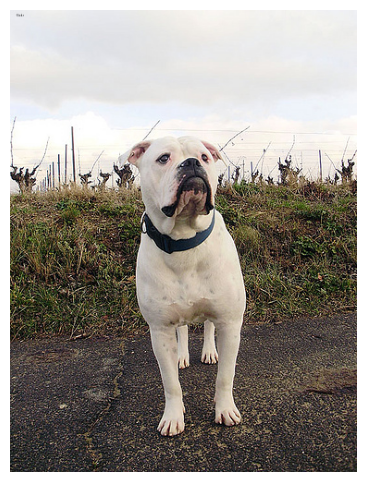

In [13]:
image_path = "/content/dog_1.jpg"

img = Image.open(image_path).convert("RGB")

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.show()

In [14]:
inputs = class_processor(images=img, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = class_model(**inputs)
    logits = outputs.logits
    predicted_class_id = logits.argmax(-1).item()

predicted_label = class_model.config.id2label[predicted_class_id]

print("Predicted class ID:", predicted_class_id)
print("Predicted label:", predicted_label)

Predicted class ID: 179
Predicted label: Staffordshire bullterrier, Staffordshire bull terrier
